In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


# **Model: Linear Regression on Lag Features**

AutoReg and ARMA both work directly on the raw series, but a plain `LinearRegression`
can do basically the same job if I manually build the lag columns myself first --
worth trying since it's a genuinely different implementation path even though the
underlying idea (predict from past values) is the same.

In [2]:
def load_series(path):
    s = pd.read_csv(path, index_col=0, parse_dates=True)
    return s.iloc[:, 0]

y_train = load_series("../data/y_train.csv")
y_test = load_series("../data/y_test.csv")

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (2635,)
y_test shape: (293,)


# **Cleaning columns / feature engineering**

In [3]:
# testing lag feature creation loose before wrapping into a function
n_lags = 5
df_test = pd.DataFrame({"y": y_train})
for lag in range(1, n_lags + 1):
    df_test[f"lag_{lag}"] = df_test["y"].shift(lag)

df_test = df_test.dropna()
df_test.head()

,y,lag_1,lag_2,lag_3,lag_4,lag_5
timestamp,,,,,,
2018-09-01 05:00:00+03:00,21.016667,17.665000,11.614167,11.420000,15.800000,17.541667
2018-09-01 06:00:00+03:00,22.589167,21.016667,17.665000,11.614167,11.420000,15.800000
2018-09-01 07:00:00+03:00,18.605833,22.589167,21.016667,17.665000,11.614167,11.420000
2018-09-01 08:00:00+03:00,14.022500,18.605833,22.589167,21.016667,17.665000,11.614167
2018-09-01 09:00:00+03:00,13.150000,14.022500,18.605833,22.589167,21.016667,17.665000


In [4]:
# good, wrap into a function so train and test get identical treatment
def make_lag_features(series, n_lags, history=None):
    """Build lag columns for a series. If `history` is given, use it to fill in the
    lags for the first few rows of `series` (needed for the test set, since its first
    few lags fall inside the training period)."""
    combined = pd.concat([history, series]) if history is not None else series
    df = pd.DataFrame({"y": combined})
    for lag in range(1, n_lags + 1):
        df[f"lag_{lag}"] = df["y"].shift(lag)
    df = df.dropna()
    return df.loc[series.index.intersection(df.index)]


# **Hyper parameter Tuning**

In [5]:
# looping over how many lags to include, same pattern as the AR model's p search
lag_options = range(1, 31)
maes = []

for n_lags in lag_options:
    df = make_lag_features(y_train, n_lags)
    X = df.drop(columns="y")
    y = df["y"]

    m = LinearRegression().fit(X, y)
    y_pred = m.predict(X)
    maes.append(mean_absolute_error(y, y_pred))

mae_series = pd.Series(maes, index=lag_options, name="mae")
mae_series.sort_values().head()

29    2.347406
30    2.347586
28    2.350538
27    2.353483
26    2.353816
Name: mae, dtype: float64

In [6]:
best_n_lags = mae_series.idxmin()
print("Best number of lags:", best_n_lags)

Best number of lags: 29


# **Build Model**

In [7]:
df_train = make_lag_features(y_train, best_n_lags)
X_train = df_train.drop(columns="y")
y_train_target = df_train["y"]

model = LinearRegression().fit(X_train, y_train_target)


# **Evaluate**

In [8]:
y_pred_train = model.predict(X_train)
train_mae = mean_absolute_error(y_train_target, y_pred_train)
print("Train MAE:", round(train_mae, 2))

Train MAE: 2.35


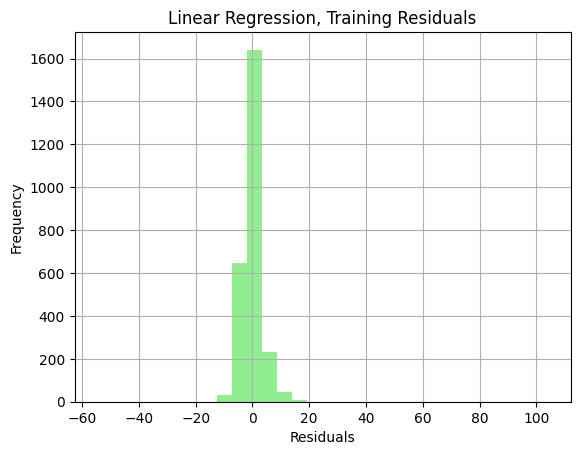

In [9]:
y_train_resid = y_train_target - y_pred_train
y_train_resid.name = "residuals"

y_train_resid.hist(bins=30, color="lightgreen")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Linear Regression, Training Residuals")
plt.savefig("../images/linreg_residuals_hist.png", dpi=150)
plt.show()


# **Walk-Forward Validation**

Same idea as the AR model -- predict one hour ahead, then fold the real observed value
into history before predicting the next one. Refitting the whole regression at every
step (not just updating lags), so it stays a fair apples-to-apples comparison with the
AR model's walk-forward setup.

In [10]:
preds = []
history = y_train.copy()

for i in range(len(y_test)):
    df_hist = make_lag_features(history, best_n_lags)
    X_hist = df_hist.drop(columns="y")
    y_hist = df_hist["y"]
    m = LinearRegression().fit(X_hist, y_hist)

    # build the feature row for the next timestamp using the most recent lags
    last_lags = history.iloc[-best_n_lags:].values[::-1]
    X_next = pd.DataFrame([last_lags], columns=X_hist.columns)
    next_pred = m.predict(X_next)[0]

    preds.append(next_pred)
    history = pd.concat([history, y_test.iloc[[i]]])

y_pred_wfv = pd.Series(preds, index=y_test.index, name="prediction")
y_pred_wfv.head()

timestamp
2018-12-19 19:00:00+03:00    10.218673
2018-12-19 20:00:00+03:00    13.996343
2018-12-19 21:00:00+03:00    13.775455
2018-12-19 22:00:00+03:00    13.125713
2018-12-19 23:00:00+03:00    11.416920
Name: prediction, dtype: float64

In [11]:
test_mae = mean_absolute_error(y_test, y_pred_wfv)
print("Test MAE (walk-forward validation):", round(test_mae, 2))

Test MAE (walk-forward validation): 1.24


# **Communicate Results**

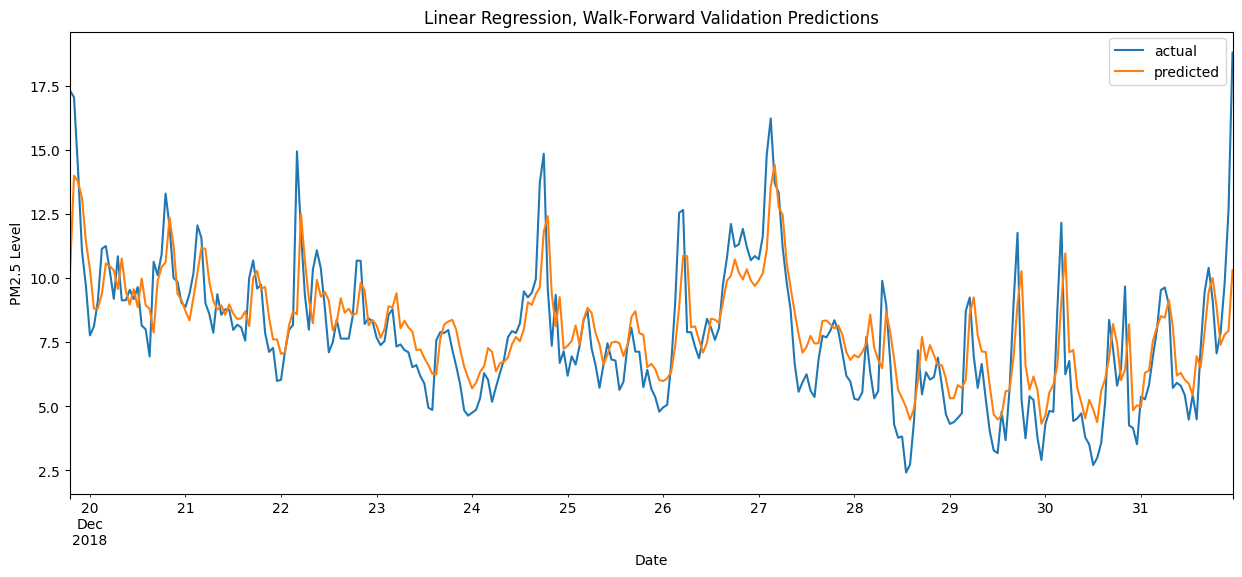

In [12]:
fig, ax = plt.subplots(figsize=(15,6))
y_test.plot(ax=ax, label="actual")
y_pred_wfv.plot(ax=ax, label="predicted")
plt.xlabel("Date")
plt.ylabel("PM2.5 Level")
plt.title("Linear Regression, Walk-Forward Validation Predictions")
plt.legend()
plt.savefig("../images/linreg_wfv_predictions.png", dpi=150)
plt.show()


In [13]:
with open("../data/4_model_linreg_results.txt", "w") as f:
    f.write(str(test_mae))
print("saved:", test_mae)

saved: 1.237517986628757
